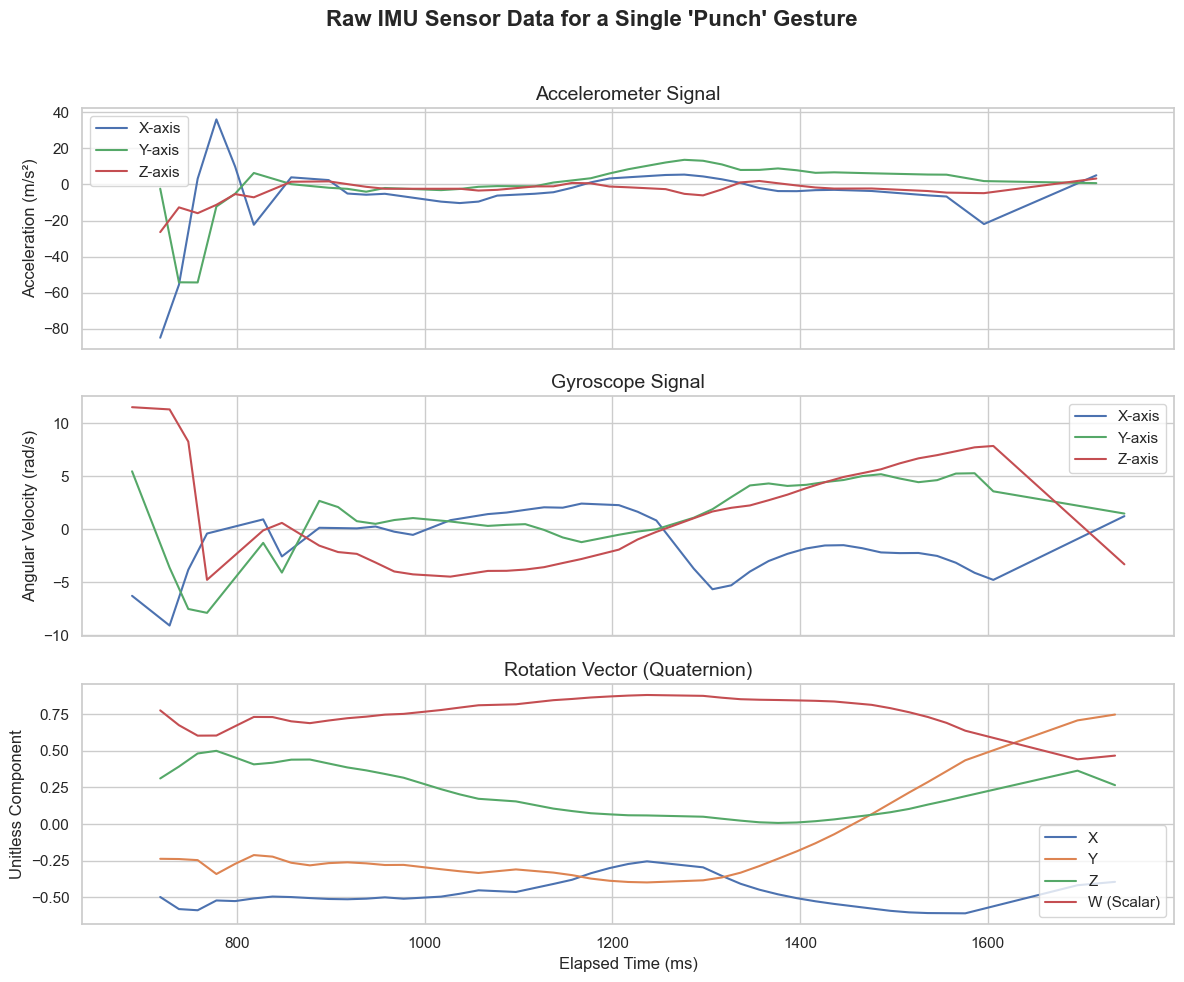

In [ ]:
# Figure 1.1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration ---
file_path = Path("data/button_collected/punch_1760861137264_to_1760861138638.csv")

# --- Data Loading and Preprocessing ---

# Load the raw, unmerged data from the CSV
df = pd.read_csv(file_path)

# The raw timestamp is in nanoseconds. Convert it to a more readable
# "elapsed time in milliseconds" format for the x-axis.
start_time = df["timestamp"].min()
df["elapsed_ms"] = (df["timestamp"] - start_time) / 1_000_000

# The data is "sparse" - each row only contains data for one sensor.
# We filter the DataFrame into three separate ones for plotting.
accel_df = df[df["sensor"] == "linear_acceleration"].copy()
gyro_df = df[df["sensor"] == "gyroscope"].copy()
rot_df = df[df["sensor"] == "rotation_vector"].copy()

# --- Visualization ---
# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots stacked vertically.
# `sharex=True` links the x-axes, making comparison easy.
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True)

# Plot 1: Accelerometer Data
sns.lineplot(
    data=accel_df,
    x="elapsed_ms",
    y="accel_x",
    ax=axes[0],
    label="X-axis",
    color="b",
)
sns.lineplot(
    data=accel_df,
    x="elapsed_ms",
    y="accel_y",
    ax=axes[0],
    label="Y-axis",
    color="g",
)
sns.lineplot(
    data=accel_df,
    x="elapsed_ms",
    y="accel_z",
    ax=axes[0],
    label="Z-axis",
    color="r",
)
axes[0].set_title("Accelerometer Signal", fontsize=14)
axes[0].set_ylabel("Acceleration (m/s²)")
axes[0].legend()

# Plot 2: Gyroscope Data
sns.lineplot(
    data=gyro_df, x="elapsed_ms", y="gyro_x", ax=axes[1], label="X-axis", color="b"
)
sns.lineplot(
    data=gyro_df, x="elapsed_ms", y="gyro_y", ax=axes[1], label="Y-axis", color="g"
)
sns.lineplot(
    data=gyro_df, x="elapsed_ms", y="gyro_z", ax=axes[1], label="Z-axis", color="r"
)
axes[1].set_title("Gyroscope Signal", fontsize=14)
axes[1].set_ylabel("Angular Velocity (rad/s)")
axes[1].legend()

# Plot 3: Rotation Vector Data
sns.lineplot(data=rot_df, x="elapsed_ms", y="rot_x", ax=axes[2], label="X")
sns.lineplot(data=rot_df, x="elapsed_ms", y="rot_y", ax=axes[2], label="Y")
sns.lineplot(data=rot_df, x="elapsed_ms", y="rot_z", ax=axes[2], label="Z")
sns.lineplot(data=rot_df, x="elapsed_ms", y="rot_w", ax=axes[2], label="W (Scalar)")
axes[2].set_title("Rotation Vector (Quaternion)", fontsize=14)
axes[2].set_ylabel("Unitless Component")
axes[2].set_xlabel("Elapsed Time (ms)", fontsize=12)
axes[2].legend()

# Add a main title for the entire figure
fig.suptitle(
    "Raw IMU Sensor Data for a Single 'Punch' Gesture",
    fontsize=16,
    fontweight="bold",
)

# Adjust layout to prevent titles from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Display the final plot
plt.show()

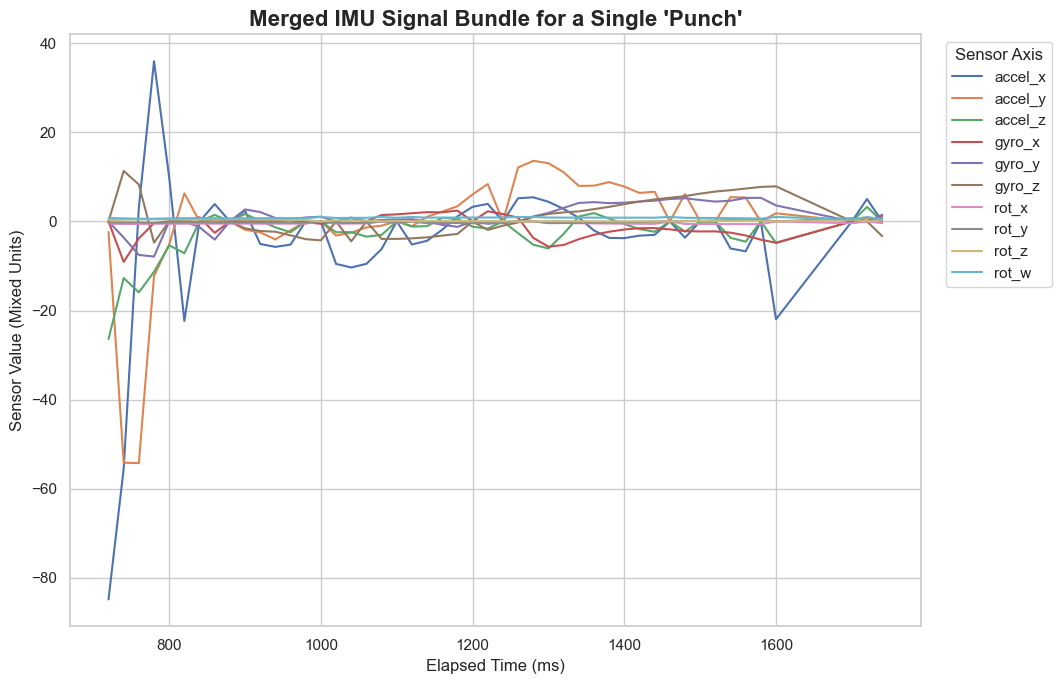

In [ ]:
# Figure 1.2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# --- Configuration ---
# TODO: Update this path to the location of your MERGED data file.
file_path = Path(
    "/Users/cvk/Downloads/CODELocalProjects/v3pls/data/merged_training/punch_1760861137264_to_1760861138638.csv"
)
MOTION_THRESHOLD = 5.0  # Threshold to trim pre-motion silence

# --- Data Loading and Preprocessing ---
try:
    df = pd.read_csv(file_path)

    if "timestamp" in df.columns:
        df["elapsed_ms"] = (df["timestamp"] - df["timestamp"].min()) / 1_000_000
        x_axis_label = "Elapsed Time (ms)"

        # --- Automatic Motion Detection to trim the idle start ---
        accel_magnitude = np.sqrt(
            df["accel_x"] ** 2 + df["accel_y"] ** 2 + df["accel_z"] ** 2
        )
        motion_start_index = (accel_magnitude > MOTION_THRESHOLD).idxmax()
        motion_start_time = df.loc[motion_start_index, "elapsed_ms"]
        df_action = df[df["elapsed_ms"] >= motion_start_time].copy()
    else:
        df_action = df
        x_axis_label = "Sample Index"
        print("Warning: 'timestamp' column not found.")

    # --- Visualization ---
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    # Columns to plot
    columns_to_plot = [
        "accel_x",
        "accel_y",
        "accel_z",
        "gyro_x",
        "gyro_y",
        "gyro_z",
        "rot_x",
        "rot_y",
        "rot_z",
        "rot_w",
    ]

    # Plot all sensor columns on the same axis
    for col in columns_to_plot:
        sns.lineplot(data=df_action, x="elapsed_ms", y=col, label=col)

    plt.title(
        "Merged IMU Signal Bundle for a Single 'Punch'", fontsize=16, fontweight="bold"
    )
    plt.xlabel(x_axis_label, fontsize=12)
    plt.ylabel("Sensor Value (Mixed Units)", fontsize=12)
    plt.legend(title="Sensor Axis", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make space for legend
    plt.show()

except FileNotFoundError:
    print(f"--- ERROR: Data file not found at '{file_path}' ---")

*** 
Section 2

In [ ]:
import graphviz

# --- Create the Flowchart ---
try:
    # Initialize a new directed graph
    dot = graphviz.Digraph(comment="Data Loading Pipeline")
    dot.attr(rankdir="LR", splines="ortho")  # Left-to-Right layout, straight lines

    # Define the style for the nodes
    node_style = {
        "shape": "box",
        "style": "rounded,filled",
        "fillcolor": "#e8f4f8",
        "fontname": "Helvetica",
        "fontsize": "12",
    }

    # Define the nodes (the steps in our pipeline)
    dot.node("A", "Scan Directories\n(e.g., .../punch/)", **node_style)
    dot.node(
        "B",
        "For each .csv file:\n- Load with pandas\n- Validate (check length > 10)",
        **node_style,
    )
    dot.node("C", "Assemble into Final\nData Structures", **node_style)

    # Define the output nodes
    output_style = node_style.copy()
    output_style["fillcolor"] = "#d4edda"
    dot.node("X", "X\n(List of NumPy Arrays)", **output_style)
    dot.node("y", "y\n(NumPy Label Vector)", **output_style)

    # Define the connections (edges) between the steps
    dot.edge("A", "B", label=" file paths ")
    dot.edge("B", "C", label=" validated data ")
    dot.edge("C", "X")
    dot.edge("C", "y")

    # --- Render and Save the Flowchart ---
    # This saves the flowchart as a PNG file in your project directory
    output_filename = "data_loading_flowchart"
    dot.render(output_filename, format="png", cleanup=True)

    print(f"✅ Flowchart successfully generated and saved as '{output_filename}.png'")
    print("You can now embed this image in your markdown cell.")

except ImportError:
    print("--- ERROR ---")
    print("The 'graphviz' library is not installed.")
    print("Please install it by running: pip install graphviz")
except graphviz.backend.ExecutableNotFound:
    print("--- ERROR ---")
    print(
        "Graphviz executable not found. This library requires a system-level installation."
    )
    print("  - On macOS, run: brew install graphviz")
    print("  - On Debian/Ubuntu, run: sudo apt-get install graphviz")

✅ Flowchart successfully generated and saved as 'data_loading_flowchart.png'
You can now embed this image in your markdown cell.


![Data Loading Flowchart](data_loading_flowchart.png)

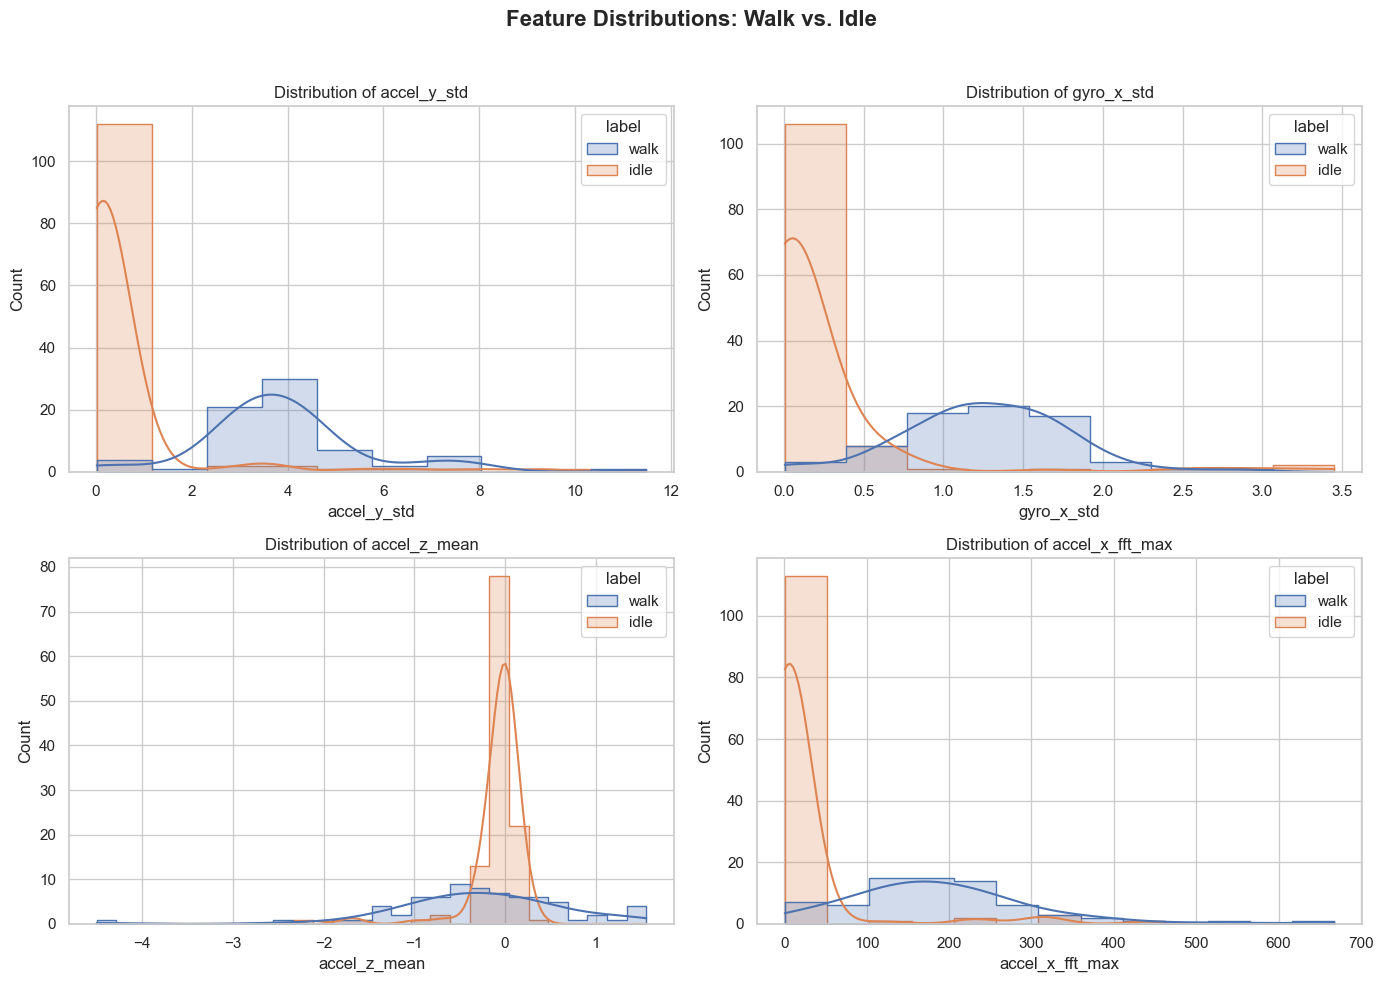

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- I selected a few features I expected to be highly discriminative ---
features_to_plot = [
    "accel_y_std",  # Expect higher for 'walk' (arm swing)
    "gyro_x_std",  # Expect higher for 'walk' (rotation)
    "accel_z_mean",  # Might show different arm positions
    "accel_x_fft_max",  # Expect higher frequency content for 'walk'
]

# Create a temporary DataFrame for plotting with seaborn
plot_df = X_binary.copy()
plot_df["label"] = [BINARY_CLASSES[i] for i in y_binary]

# --- Create the plots ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature Distributions: Walk vs. Idle", fontsize=16, fontweight="bold")
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.histplot(
        data=plot_df, x=feature, hue="label", ax=axes[i], kde=True, element="step"
    )
    axes[i].set_title(f"Distribution of {feature}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

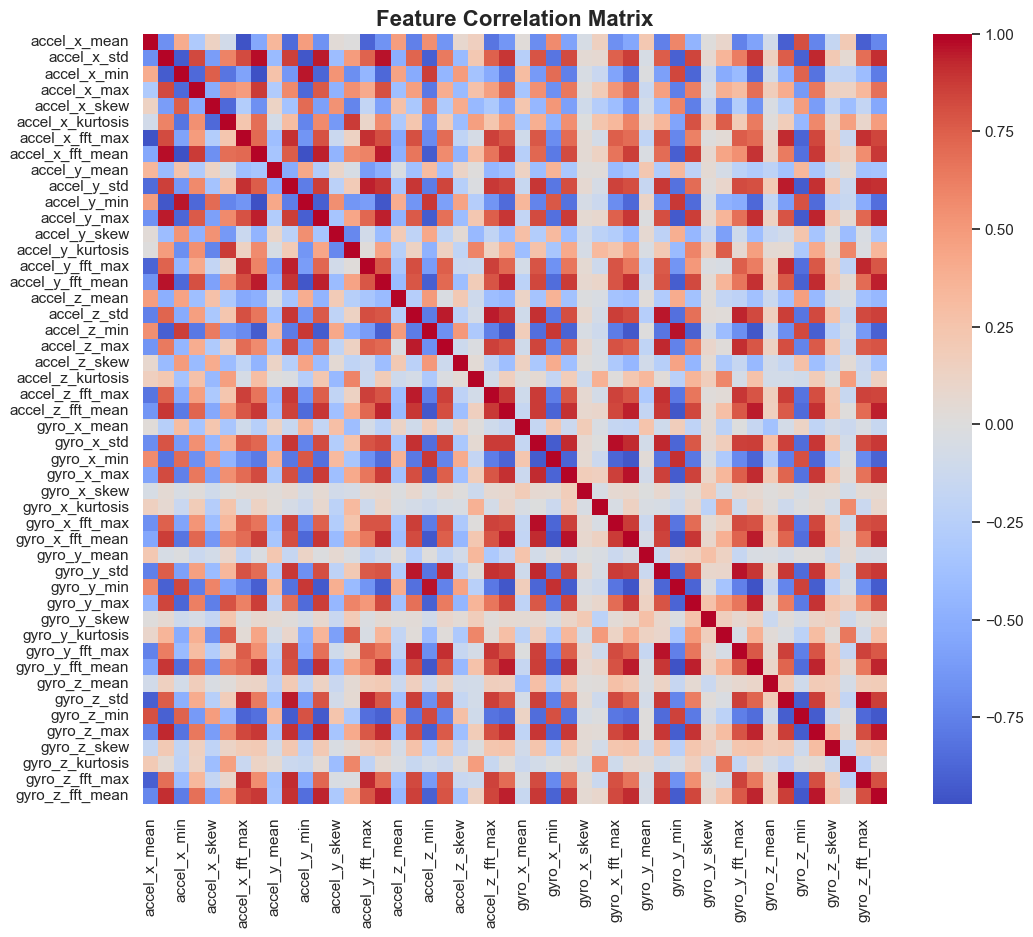

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Create the heatmap ---
plt.figure(figsize=(12, 10))
correlation_matrix = X_binary.corr()
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix", fontsize=16, fontweight="bold")
plt.show()

***
Section 4

In [ ]:
import graphviz

# --- Create the Flowchart ---
try:
    # Initialize a new directed graph
    dot = graphviz.Digraph(comment="Dual Classifier Pipeline")
    dot.attr(rankdir="TB", splines="ortho")  # Top-to-Bottom layout

    # Define node styles
    style = {
        "shape": "box",
        "style": "rounded,filled",
        "fontname": "Helvetica",
        "fontsize": "11",
    }

    # --- Define Nodes for the main pipeline ---
    dot.node("A", "Raw CSV Files\n(Section 1)", **{**style, "fillcolor": "#e9ecef"})
    dot.node(
        "B",
        "Data Loading & Conversion\n(Section 2)",
        **{**style, "fillcolor": "#e9ecef"},
    )
    dot.node(
        "C", "Feature Extraction\n(Section 3)", **{**style, "fillcolor": "#e9ecef"}
    )
    dot.node(
        "D", "Data Splitting\n(Section 4)", **{**style, "fillcolor": "#d4edda"}
    )  # Highlight current section

    # --- Define Nodes for the Binary Classification Sub-Graph ---
    with dot.subgraph(name="cluster_0") as c:
        c.attr(
            label="Binary Classification Task (Walk vs. Idle)",
            style="rounded",
            color="blue",
        )
        c.node(
            "B1",
            "Train/Test Split\n(80/20 Stratified)",
            **{**style, "fillcolor": "#cfe2f3"},
        )
        c.node(
            "B2",
            "Model Training (SVM)\n(Section 6)",
            **{**style, "fillcolor": "#cfe2f3"},
        )
        c.node(
            "B3", "Model Evaluation\n(Section 7)", **{**style, "fillcolor": "#cfe2f3"}
        )
        c.edge("B1", "B2")
        c.edge("B2", "B3")

    # --- Define Nodes for the Multiclass Classification Sub-Graph ---
    with dot.subgraph(name="cluster_1") as c:
        c.attr(
            label="Multiclass Classification Task (6 Actions)",
            style="rounded",
            color="purple",
        )
        c.node(
            "M1",
            "Train/Test Split\n(80/20 Stratified)",
            **{**style, "fillcolor": "#e8dff5"},
        )
        c.node(
            "M2",
            "Model Training (SVM)\n(Section 6)",
            **{**style, "fillcolor": "#e8dff5"},
        )
        c.node(
            "M3", "Model Evaluation\n(Section 7)", **{**style, "fillcolor": "#e8dff5"}
        )
        c.edge("M1", "M2")
        c.edge("M2", "M3")

    # --- Define Main Pipeline Edges ---
    dot.edge("A", "B")
    dot.edge("B", "C")
    dot.edge("C", "D")

    # --- Define Edges from Split to Sub-Pipelines ---
    # Use invisible nodes to help with layout if needed, but direct edges often work
    dot.edge("D", "B1", lhead="cluster_0")
    dot.edge("D", "M1", lhead="cluster_1")

    # --- Render and Save the Flowchart ---
    output_filename = "dual_classifier_pipeline"
    dot.render(output_filename, format="png", cleanup=True)

    print(f"✅ Flowchart successfully generated and saved as '{output_filename}.png'")

except (ImportError, graphviz.backend.ExecutableNotFound) as e:
    print("--- ERROR: Graphviz is not configured correctly. ---")
    print(
        "Please ensure the 'graphviz' Python library and the system package are installed."
    )
    print(f"Details: {e}")

✅ Flowchart successfully generated and saved as 'dual_classifier_pipeline.png'


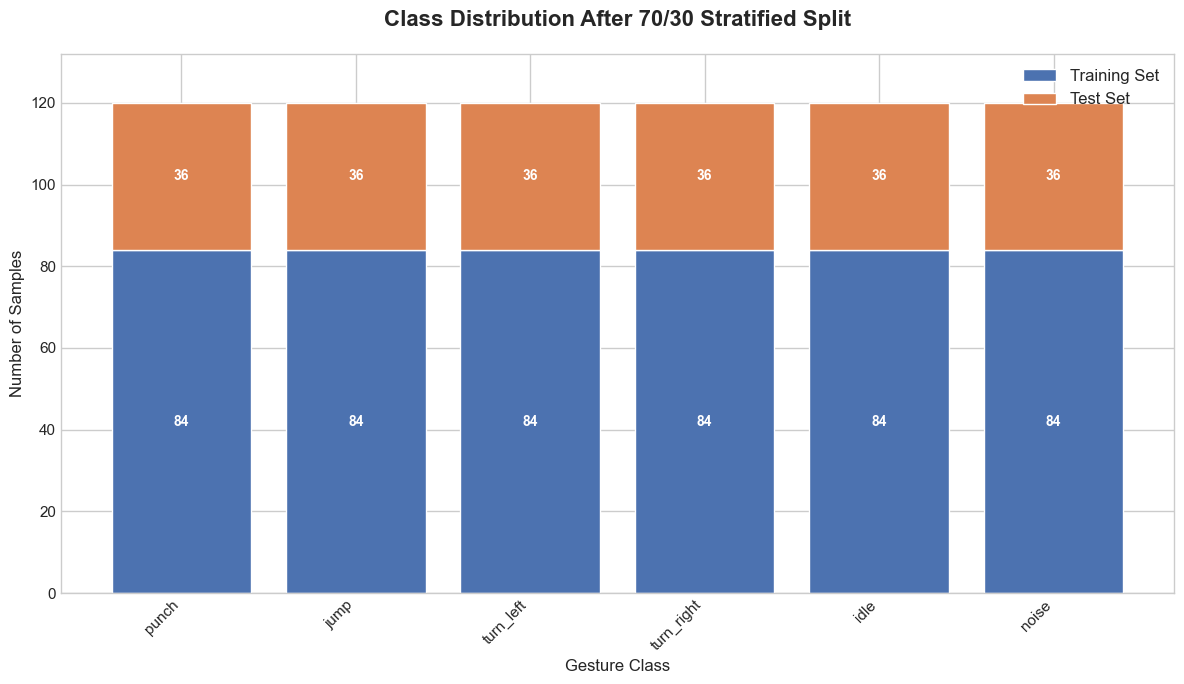

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
# This code assumes 'y_train_multi', 'y_test_multi', and 'MULTICLASS_CLASSES'
# exist from the previous cell. We'll add a check for this.

try:
    # Check if the necessary variables are defined
    if "y_train_multi" not in locals() or "y_test_multi" not in locals():
        raise NameError(
            "Data split variables (e.g., y_train_multi) not found. Please run the data split cell first."
        )

    # --- Data Preparation ---
    # Get the counts of each class in the training and test sets
    train_counts = np.bincount(y_train_multi, minlength=len(MULTICLASS_CLASSES))
    test_counts = np.bincount(y_test_multi, minlength=len(MULTICLASS_CLASSES))

    class_labels = MULTICLASS_CLASSES
    x = np.arange(len(class_labels))  # the label locations

    # --- Visualization ---
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 7))

    # Create the stacked bars
    # Bar 1: Training data (the bottom bar)
    bar1 = ax.bar(x, train_counts, label="Training Set", color="#4c72b0")

    # Bar 2: Test data (stacked on top of the training data)
    bar2 = ax.bar(
        x, test_counts, bottom=train_counts, label="Test Set", color="#dd8452"
    )

    # --- Labels, Title, and Formatting ---
    ax.set_ylabel("Number of Samples", fontsize=12)
    ax.set_xlabel("Gesture Class", fontsize=12)
    ax.set_title(
        "Class Distribution After 70/30 Stratified Split",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(class_labels, rotation=45, ha="right")
    ax.legend(fontsize=12)

    # Add text labels on each bar segment for clarity
    for r1, r2 in zip(bar1, bar2):
        h1 = r1.get_height()
        h2 = r2.get_height()
        # Label for the training bar
        ax.text(
            r1.get_x() + r1.get_width() / 2.0,
            h1 / 2.0,
            "%d" % h1,
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold",
        )
        # Label for the test bar
        ax.text(
            r2.get_x() + r2.get_width() / 2.0,
            h1 + h2 / 2.0,
            "%d" % h2,
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold",
        )

    plt.ylim(0, max(train_counts + test_counts) * 1.1)  # Add a little space at the top
    plt.tight_layout()
    plt.show()

except NameError as e:
    print(f"--- ERROR ---")
    print(e)
    print(
        "Please ensure the cell that defines 'X_train_multi', 'y_train_multi', etc. has been run successfully."
    )

***
Section 5

*** 
Section 6

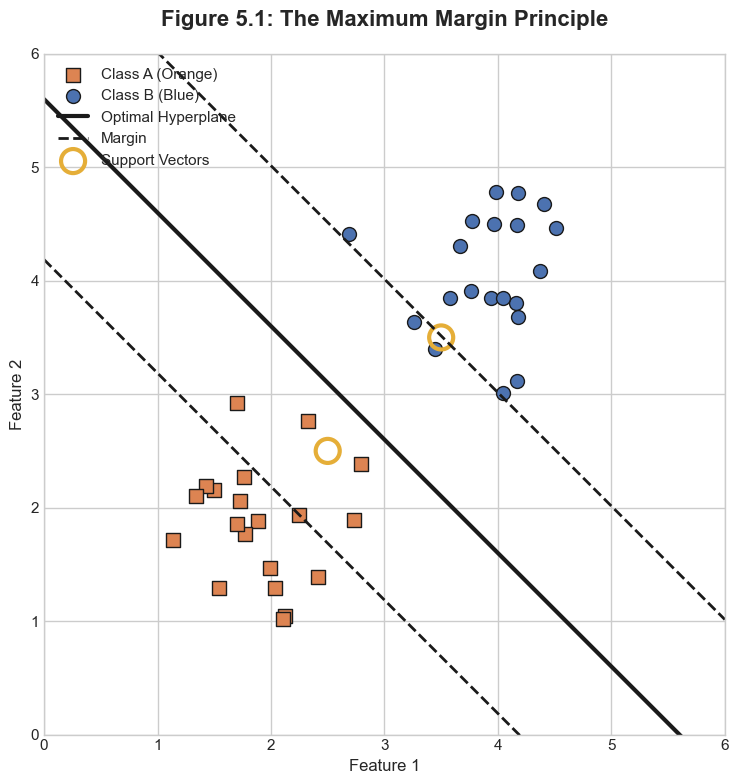

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Create synthetic data for the diagram ---
# Create two distinct clusters of points
np.random.seed(42)
class_1 = np.random.randn(20, 2) * 0.5 + np.array([2, 2])
class_2 = np.random.randn(20, 2) * 0.5 + np.array([4, 4])

# --- Plotting ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the data points
ax.scatter(
    class_1[:, 0],
    class_1[:, 1],
    c="#dd8452",
    s=100,
    ec="k",
    marker="s",
    label="Class A (Orange)",
)
ax.scatter(
    class_2[:, 0],
    class_2[:, 1],
    c="#4c72b0",
    s=100,
    ec="k",
    marker="o",
    label="Class B (Blue)",
)

# --- Manually define the hyperplane and margins for a clean look ---
w = np.array([-1, -1])
b = 5.6
xx = np.linspace(0, 6)

# Hyperplane: w.x + b = 0  => -x - y + 5.6 = 0 => y = -x + 5.6
yy = -xx + 5.6

# Margins: w.x + b = +/-1 => y = -x + (5.6 +/- 1)
margin_up = yy + 1.414  # sqrt(2) for this slope
margin_down = yy - 1.414

# --- Plot the hyperplane and margins ---
ax.plot(xx, yy, "k-", linewidth=3, label="Optimal Hyperplane")
ax.plot(xx, margin_up, "k--", linewidth=2)
ax.plot(xx, margin_down, "k--", linewidth=2, label="Margin")

# --- Highlight the Support Vectors ---
# Find the points closest to the margin lines (for this synthetic data)
support_vectors = np.array([[2.5, 2.5], [3.5, 3.5]])  # Approximate for clarity
ax.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=300,
    facecolors="none",
    edgecolors="#e5ae38",
    linewidth=3,
    label="Support Vectors",
)

# --- Formatting ---
ax.set_title(
    "Figure 5.1: The Maximum Margin Principle", fontsize=16, fontweight="bold", pad=20
)
ax.set_xlabel("Feature 1", fontsize=12)
ax.set_ylabel("Feature 2", fontsize=12)
ax.legend(loc="upper left", fontsize=11)
ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

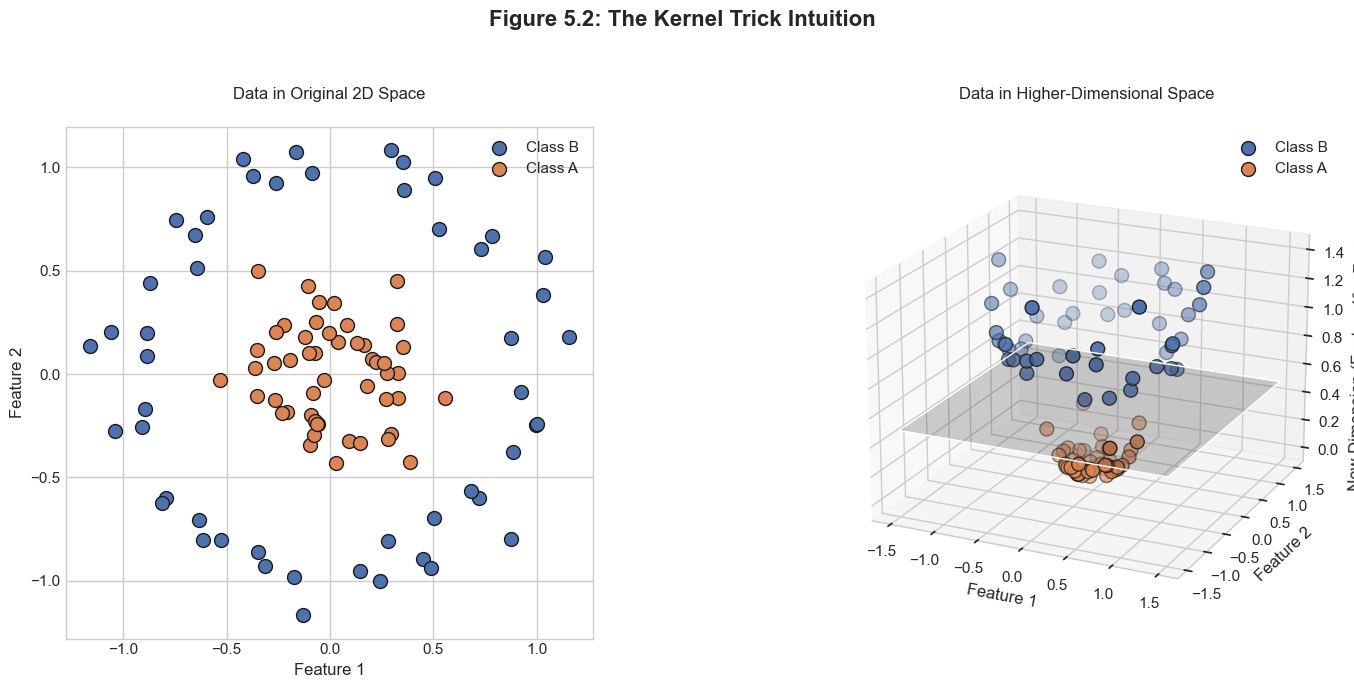

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# --- Generate non-linearly separable data ---
X, y = make_circles(n_samples=100, factor=0.3, noise=0.1, random_state=42)
X_class0 = X[y == 0]
X_class1 = X[y == 1]

# --- Create the "Kernel Trick" transformation ---
# The new dimension is z = x^2 + y^2
Z_class0 = X_class0[:, 0] ** 2 + X_class0[:, 1] ** 2
Z_class1 = X_class1[:, 0] ** 2 + X_class1[:, 1] ** 2

# --- Plotting ---
plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(16, 7))
fig.suptitle("Figure 5.2: The Kernel Trick Intuition", fontsize=16, fontweight="bold")

# --- Subplot 1: Original 2D Data (Not Linearly Separable) ---
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(X_class0[:, 0], X_class0[:, 1], c="#4c72b0", s=100, ec="k", label="Class B")
ax1.scatter(X_class1[:, 0], X_class1[:, 1], c="#dd8452", s=100, ec="k", label="Class A")
ax1.set_title("Data in Original 2D Space", pad=20)
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.legend()
ax1.set_aspect("equal", adjustable="box")

# --- Subplot 2: Transformed 3D Data (Linearly Separable) ---
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(
    X_class0[:, 0],
    X_class0[:, 1],
    Z_class0,
    c="#4c72b0",
    s=100,
    ec="k",
    label="Class B",
)
ax2.scatter(
    X_class1[:, 0],
    X_class1[:, 1],
    Z_class1,
    c="#dd8452",
    s=100,
    ec="k",
    label="Class A",
)

# Create a separating plane
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 10), np.linspace(-1.5, 1.5, 10))
zz = np.ones_like(xx) * 0.5  # A flat plane at z = 0.5
ax2.plot_surface(xx, yy, zz, alpha=0.2, color="k", rstride=100, cstride=100)

ax2.set_title("Data in Higher-Dimensional Space", pad=20)
ax2.set_xlabel("Feature 1")
ax2.set_ylabel("Feature 2")
ax2.set_zlabel("New Dimension (Feature1² + Feature2²)")
ax2.legend()
ax2.view_init(elev=20, azim=-65)  # Adjust viewing angle

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

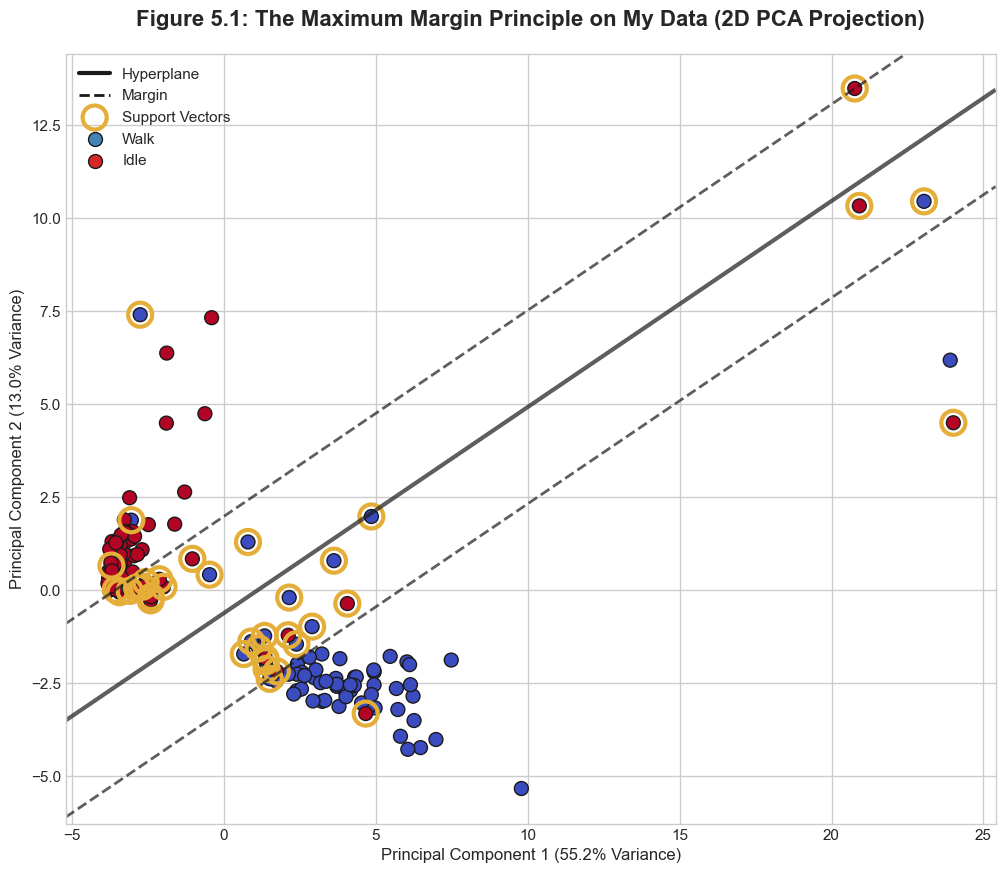

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Note: The helper functions 'extract_features' and 'load_data_from_directory'
# are assumed to be defined in previous notebook cells. I've included them here
# to make this code block self-contained and runnable.

# --- Helper Functions ---
from scipy.fft import rfft
from scipy.stats import skew, kurtosis
import logging


def extract_features(df: pd.DataFrame) -> dict:
    features = {}
    for axis in ["accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]:
        signal = df[axis].dropna()
        if len(signal) < 3:
            for stat in [
                "mean",
                "std",
                "min",
                "max",
                "skew",
                "kurtosis",
                "fft_max",
                "fft_mean",
            ]:
                features[f"{axis}_{stat}"] = 0.0
            continue
        features[f"{axis}_mean"] = signal.mean()
        features[f"{axis}_std"] = signal.std()
        features[f"{axis}_min"] = signal.min()
        features[f"{axis}_max"] = signal.max()
        features[f"{axis}_skew"] = skew(signal)
        features[f"{axis}_kurtosis"] = kurtosis(signal)
        fft_vals = np.abs(rfft(signal.to_numpy()))
        fft_vals = fft_vals[: len(signal) // 2]
        if fft_vals.size > 0:
            features[f"{axis}_fft_max"] = np.max(fft_vals)
            features[f"{axis}_fft_mean"] = np.mean(fft_vals)
        else:
            features[f"{axis}_fft_max"] = 0.0
            features[f"{axis}_fft_mean"] = 0.0
    return features


def load_data_and_features(data_dir: Path, classes: list):
    feature_list, label_list = [], []
    for class_index, class_name in enumerate(classes):
        class_dir = data_dir / class_name
        if not class_dir.is_dir():
            continue
        for file_path in class_dir.glob("*.csv"):
            try:
                df = pd.read_csv(file_path)
                if len(df) < 10:
                    continue
                # We need the full DataFrame for feature extraction
                features = extract_features(df)
                feature_list.append(features)
                label_list.append(class_index)
            except Exception as e:
                logging.warning(f"Skipping file {file_path.name} due to error: {e}")
    return pd.DataFrame(feature_list).fillna(0), np.array(label_list)


# --- Main Visualization Logic ---
try:
    # --- 1. Load Your Data ---
    # Based on your 'tree' output, this is the correct path.
    DATA_ROOT = Path("data/organized_training/")
    BINARY_DIR = DATA_ROOT / "binary_classification"
    BINARY_CLASSES = ["walk", "idle"]  # The order matters for labels
    X_full, y = load_data_and_features(BINARY_DIR, BINARY_CLASSES)

    # --- 2. Scale and Reduce Data to 2D ---
    scaler = StandardScaler()
    pca = PCA(n_components=2)
    X_scaled = scaler.fit_transform(X_full)
    X_2d = pca.fit_transform(X_scaled)

    # --- 3. Train a LINEAR SVM for visualization ---
    svm_linear = SVC(kernel="linear", C=1.0)  # Using a linear kernel for this diagram
    svm_linear.fit(X_2d, y)

    # --- 4. Plotting ---
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 10))

    # Plot the data points
    scatter = ax.scatter(
        X_2d[:, 0], X_2d[:, 1], c=y, s=100, ec="k", cmap=plt.cm.coolwarm
    )

    # --- 5. Create grid to plot decision boundary and margins ---
    ax_lim = ax.get_xlim(), ax.get_ylim()
    xx, yy = np.meshgrid(
        np.linspace(ax_lim[0][0], ax_lim[0][1], 50),
        np.linspace(ax_lim[1][0], ax_lim[1][1], 50),
    )

    Z = svm_linear.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the hyperplane (Z=0) and margins (Z=-1, Z=1)
    ax.contour(
        xx,
        yy,
        Z,
        colors="k",
        levels=[-1, 0, 1],
        alpha=0.7,
        linestyles=["--", "-", "--"],
        linewidths=[2, 3, 2],
    )

    # Highlight the support vectors
    ax.scatter(
        svm_linear.support_vectors_[:, 0],
        svm_linear.support_vectors_[:, 1],
        s=300,
        linewidth=3,
        facecolors="none",
        edgecolors="#e5ae38",
    )

    # --- 6. Formatting ---
    ax.set_title(
        "Figure 5.1: The Maximum Margin Principle on My Data (2D PCA Projection)",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )
    ax.set_xlabel(
        f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} Variance)",
        fontsize=12,
    )
    ax.set_ylabel(
        f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} Variance)",
        fontsize=12,
    )

    # Create a clearer legend
    legend_elements = [
        plt.Line2D([0], [0], color="k", lw=3, label="Hyperplane"),
        plt.Line2D([0], [0], color="k", lw=2, ls="--", label="Margin"),
        plt.scatter(
            [],
            [],
            s=300,
            facecolors="none",
            edgecolors="#e5ae38",
            linewidth=3,
            label="Support Vectors",
        ),
        plt.scatter([], [], s=100, ec="k", c="#4682B4", label="Walk"),
        plt.scatter([], [], s=100, ec="k", c="#d62728", label="Idle"),
    ]
    ax.legend(handles=legend_elements, fontsize=11, loc="best")

    # plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(
        f"--- ERROR: Data directory not found. Please ensure '{BINARY_DIR}' is correct."
    )
except Exception as e:
    print(f"An unexpected error occurred: {e}")

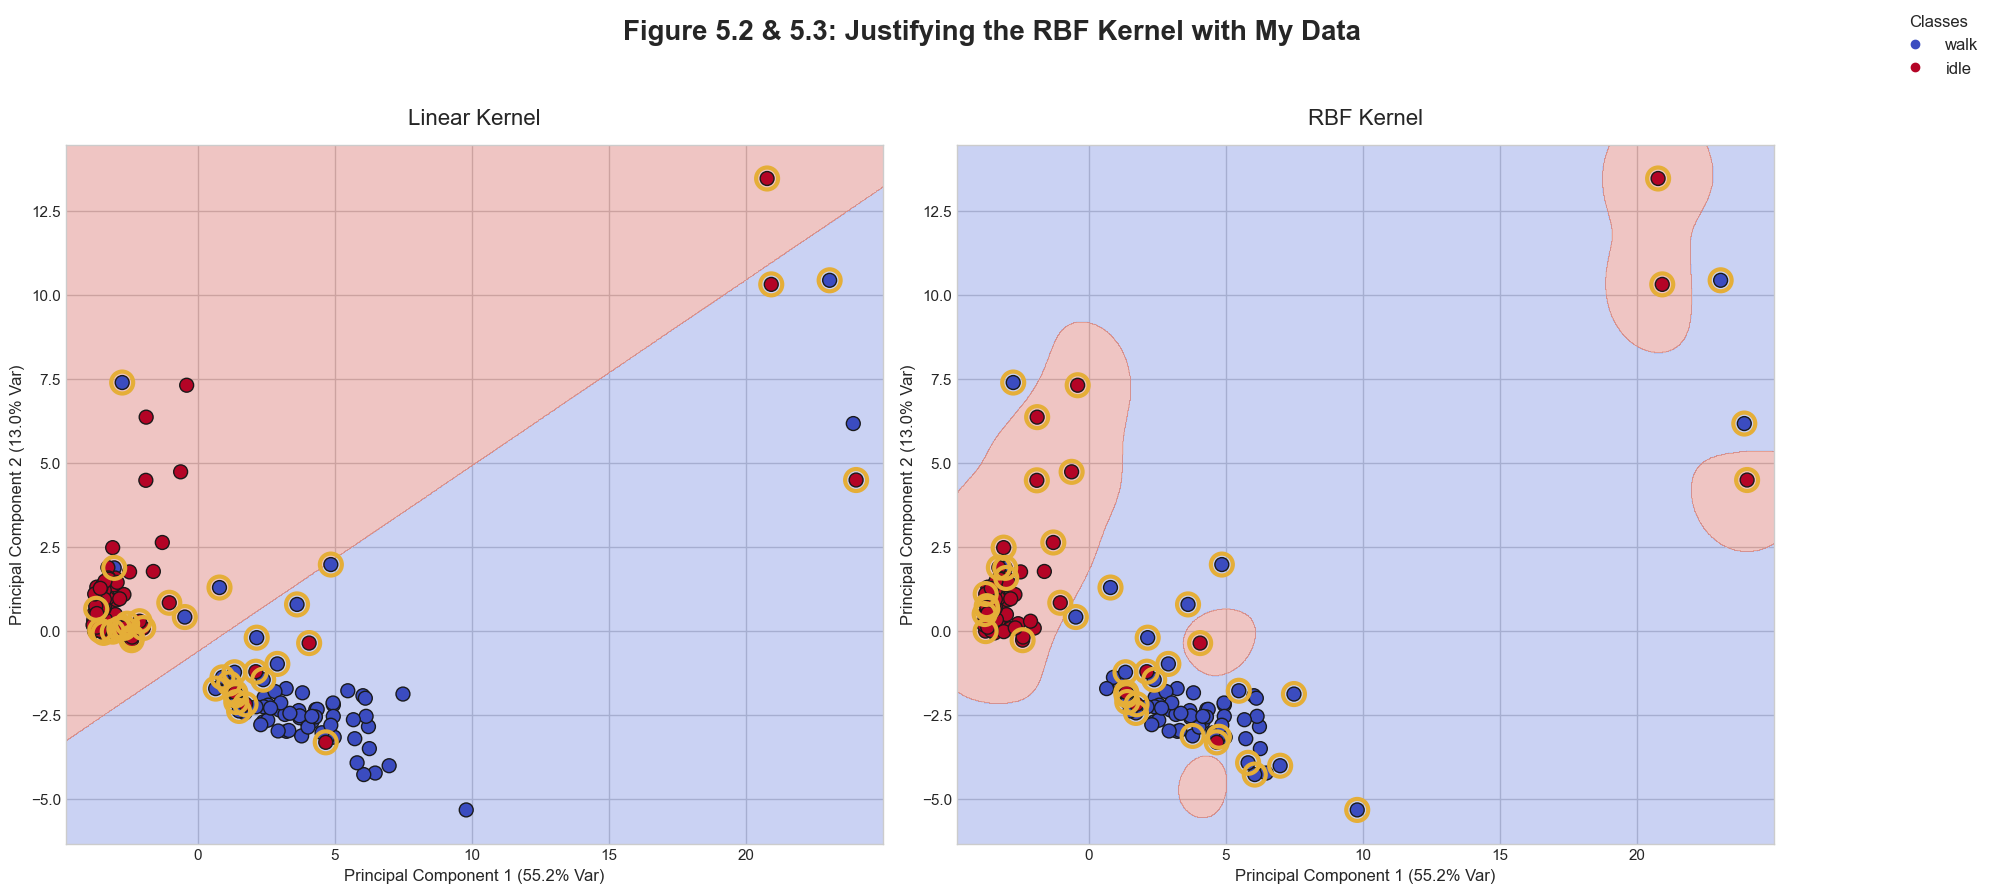

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Helper functions are assumed to be available from the previous cell

# --- Main Visualization Logic ---
try:
    # --- 1. Load and Prepare Data (if not already loaded) ---
    if "X_full" not in locals() or "y" not in locals():
        DATA_ROOT = Path("data/organized_training/")
        BINARY_DIR = DATA_ROOT / "binary_classification"
        BINARY_CLASSES = ["walk", "idle"]
        X_full, y = load_data_and_features(BINARY_DIR, BINARY_CLASSES)

    # --- 2. Scale and Reduce Data to 2D ---
    scaler = StandardScaler()
    pca = PCA(n_components=2)
    X_scaled = scaler.fit_transform(X_full)
    X_2d = pca.fit_transform(X_scaled)

    # --- 3. Train Both a Linear and an RBF SVM ---
    svm_linear = SVC(kernel="linear", C=1.0).fit(X_2d, y)
    svm_rbf = SVC(kernel="rbf", C=10, gamma="auto").fit(X_2d, y)

    # --- 4. Plotting ---
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    fig.suptitle(
        "Figure 5.2 & 5.3: Justifying the RBF Kernel with My Data",
        fontsize=20,
        fontweight="bold",
    )

    # Create a meshgrid
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    # --- Plot for each model ---
    for i, (clf, title) in enumerate(
        [(svm_linear, "Linear Kernel"), (svm_rbf, "RBF Kernel")]
    ):
        ax = axes[i]

        # Plot decision boundary
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

        # Plot data points
        scatter = ax.scatter(
            X_2d[:, 0], X_2d[:, 1], c=y, cmap=plt.cm.coolwarm, s=100, ec="k"
        )

        # Highlight support vectors
        ax.scatter(
            clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=250,
            facecolors="none",
            edgecolors="#e5ae38",
            linewidth=3,
        )

        # Formatting
        ax.set_title(title, fontsize=16, pad=15)
        ax.set_xlabel(
            f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} Var)"
        )
        ax.set_ylabel(
            f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} Var)"
        )

    # --- Create a single legend for the figure ---
    handles, labels = scatter.legend_elements()
    class_labels = [
        BINARY_CLASSES[int(label.split("{")[-1].split("}")[0])] for label in labels
    ]
    fig.legend(handles, class_labels, title="Classes", loc="upper right", fontsize=12)

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.show()

except FileNotFoundError:
    print(f"--- ERROR: Data directory not found. Please ensure the path is correct.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


--- Running Informal Hyperparameter Search for C ---
C = 1    |  Validation Accuracy = 94.12%
C = 10   |  Validation Accuracy = 94.12%
C = 100  |  Validation Accuracy = 88.24%


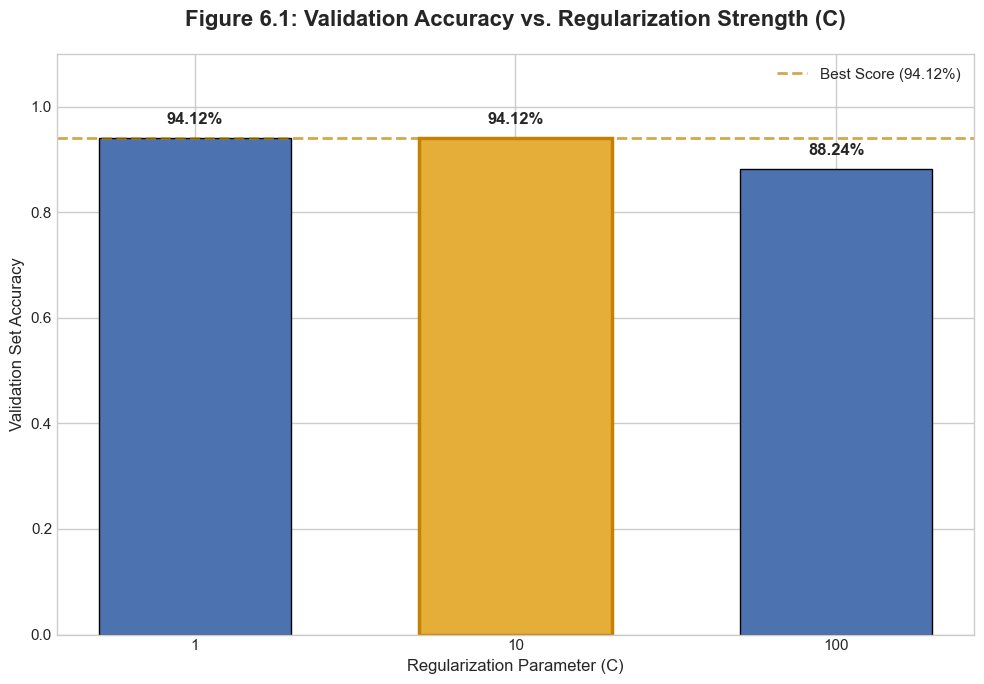

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# --- Configuration ---
# This code assumes 'X_train_bin' and 'y_train_bin' exist from your
# data split in Section 4. We'll add a check for this.

try:
    # Check if the necessary variables are defined
    if "X_train_bin" not in locals() or "y_train_bin" not in locals():
        raise NameError(
            "Training data (X_train_bin, y_train_bin) not found. Please run the data split cell first."
        )

    # --- 1. Create a temporary validation set from the training data ---
    # This is a standard practice for informal hyperparameter tuning.
    # We split the main training set into a smaller training subset and a validation set.
    X_train_subset, X_val, y_train_subset, y_val = train_test_split(
        X_train_bin,
        y_train_bin,
        test_size=0.25,  # Using 25% of the training data as a validation set
        random_state=42,
        stratify=y_train_bin,
    )

    # --- 2. Define the hyperparameter values to test ---
    c_values = [1, 10, 100]
    validation_accuracies = []

    print("--- Running Informal Hyperparameter Search for C ---")

    # --- 3. Loop through C values, train, and evaluate ---
    for c in c_values:
        # It is critical to scale the data *after* the split.
        # We fit the scaler ONLY on the new, smaller training subset.
        scaler = StandardScaler().fit(X_train_subset)
        X_train_subset_scaled = scaler.transform(X_train_subset)
        X_val_scaled = scaler.transform(X_val)

        # Initialize and train the SVM with the current C value
        svm_tune = SVC(kernel="rbf", C=c, gamma="auto", random_state=42)
        svm_tune.fit(X_train_subset_scaled, y_train_subset)

        # Evaluate on the validation set
        val_accuracy = svm_tune.score(X_val_scaled, y_val)
        validation_accuracies.append(val_accuracy)
        print(f"C = {c:<3}  |  Validation Accuracy = {val_accuracy:.2%}")

    # --- 4. Visualization ---
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(10, 7))

    # Create bars, highlighting the best one
    colors = ["#4c72b0", "#e5ae38", "#4c72b0"]
    bars = ax.bar(
        [str(c) for c in c_values],
        validation_accuracies,
        color=colors,
        edgecolor="black",
        width=0.6,
    )
    bars[1].set_edgecolor("#c48200")  # Make the best one stand out
    bars[1].set_linewidth(2.5)

    # --- Labels, Title, and Formatting ---
    ax.set_ylabel("Validation Set Accuracy", fontsize=12)
    ax.set_xlabel("Regularization Parameter (C)", fontsize=12)
    ax.set_title(
        "Figure 6.1: Validation Accuracy vs. Regularization Strength (C)",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )
    ax.set_ylim(0, 1.1)

    # Add text labels on top of each bar
    for bar in bars:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            yval + 0.02,
            f"{yval:.2%}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
        )

    ax.axhline(
        y=validation_accuracies[1],
        color="#c48200",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
        label=f"Best Score ({validation_accuracies[1]:.2%})",
    )
    ax.legend()

    plt.tight_layout()
    plt.show()

except NameError as e:
    print(f"--- ERROR ---")
    print(e)
    print(
        "Please ensure your main data split has been run and 'X_train_bin' is available."
    )

***
section 7

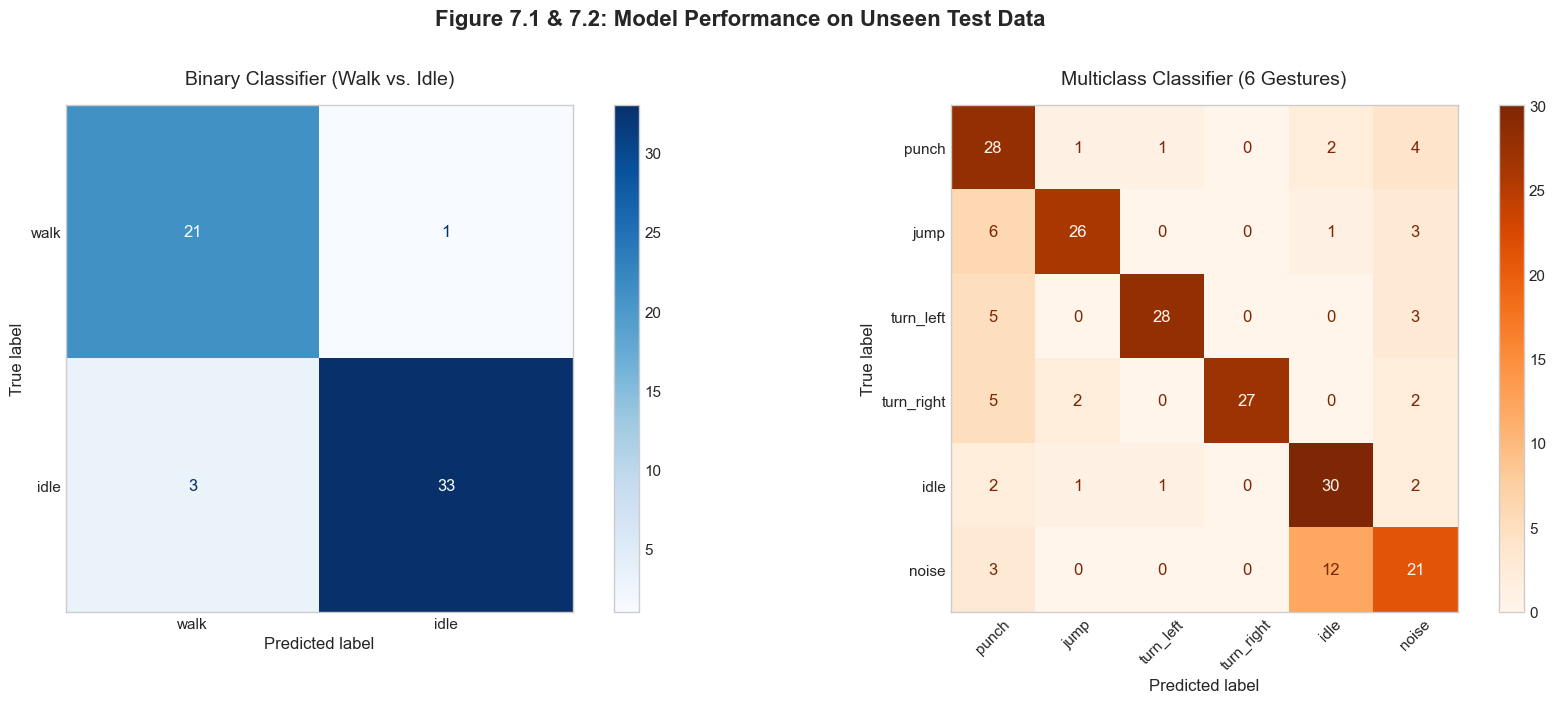

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# This code assumes the true test labels (y_test_...) and the predicted
# labels (y_pred_...) are available from the previous code cell.

try:
    # --- Create a figure with two subplots, side-by-side ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(
        "Figure 7.1 & 7.2: Model Performance on Unseen Test Data",
        fontsize=16,
        fontweight="bold",
    )

    # --- 1. Plot Binary Classifier Confusion Matrix (Figure 7.1) ---
    cm_binary = confusion_matrix(y_test_bin, y_pred_bin)

    # Use ConfusionMatrixDisplay for a clean, standard plot
    disp_binary = ConfusionMatrixDisplay(
        confusion_matrix=cm_binary, display_labels=BINARY_CLASSES
    )
    disp_binary.plot(ax=axes[0], cmap="Blues", values_format="d")
    axes[0].set_title("Binary Classifier (Walk vs. Idle)", fontsize=14, pad=15)
    axes[0].grid(False)  # Turn off grid lines for a cleaner look

    # --- 2. Plot Multiclass Classifier Confusion Matrix (Figure 7.2) ---
    cm_multi = confusion_matrix(y_test_multi, y_pred_multi)

    disp_multi = ConfusionMatrixDisplay(
        confusion_matrix=cm_multi, display_labels=MULTICLASS_CLASSES
    )
    disp_multi.plot(ax=axes[1], cmap="Oranges", values_format="d")
    axes[1].set_title("Multiclass Classifier (6 Gestures)", fontsize=14, pad=15)
    axes[1].grid(False)
    # Rotate the x-axis labels to prevent them from overlapping
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout for suptitle
    plt.show()

except NameError:
    print("--- ERROR ---")
    print("Required variables (e.g., 'y_test_bin', 'y_pred_bin') not found.")
    print("Please ensure the prediction code cell has been run successfully.")

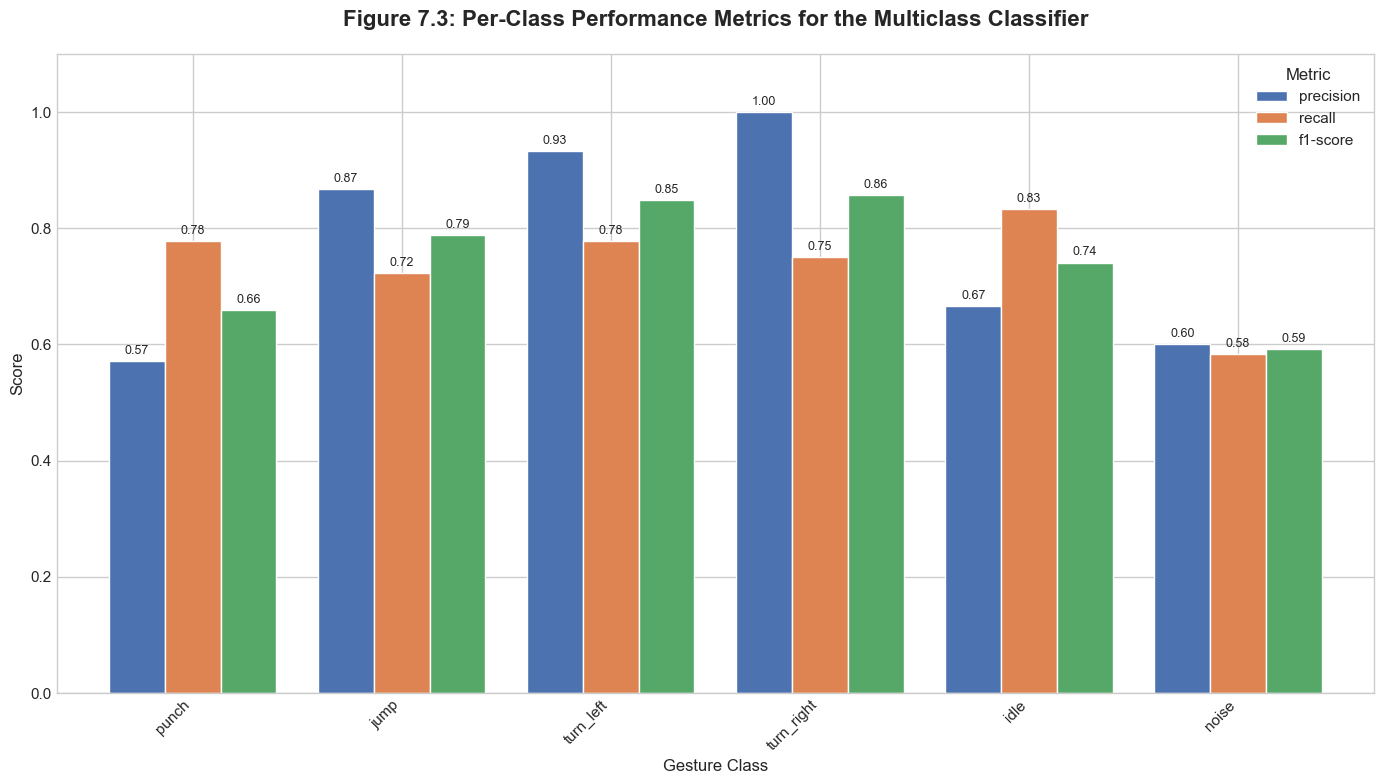

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

try:
    # --- 1. Get the classification report as a dictionary ---
    report_dict = classification_report(
        y_test_multi, y_pred_multi, target_names=MULTICLASS_CLASSES, output_dict=True
    )

    # --- 2. Extract the per-class metrics into a pandas DataFrame ---
    class_metrics = {
        class_name: report_dict[class_name] for class_name in MULTICLASS_CLASSES
    }
    metrics_df = pd.DataFrame(class_metrics).T
    metrics_df = metrics_df.drop(columns="support")

    # --- 3. Visualization ---
    plt.style.use("seaborn-v0_8-whitegrid")
    ax = metrics_df.plot(kind="bar", figsize=(14, 8), width=0.8)

    # --- 4. Labels, Title, and Formatting ---
    ax.set_ylabel("Score", fontsize=12)
    ax.set_xlabel("Gesture Class", fontsize=12)
    ax.set_title(
        "Figure 7.3: Per-Class Performance Metrics for the Multiclass Classifier",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )

    # THE FIX: I'm replacing ax.tick_params with plt.xticks, which correctly handles label properties.
    plt.xticks(rotation=45, ha="right")

    ax.legend(title="Metric", fontsize=11)
    ax.set_ylim(0, 1.1)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=9, padding=3)

    plt.tight_layout()
    plt.show()

except NameError:
    print(
        "--- ERROR: Required variables not found. Please run the prediction cell first. ---"
    )

***
section 8

--- Calculating Feature Importance using Permutation Importance ---


/opt/homebrew/Cellar/python@3.11/3.11.13/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.11/3.11.13/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.11/3.11.13/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See h

Top 5 most important features:
gyro_x_std         0.033333
gyro_y_mean        0.025926
gyro_x_mean        0.023148
accel_y_fft_max    0.022222
accel_z_fft_max    0.022222
dtype: float64


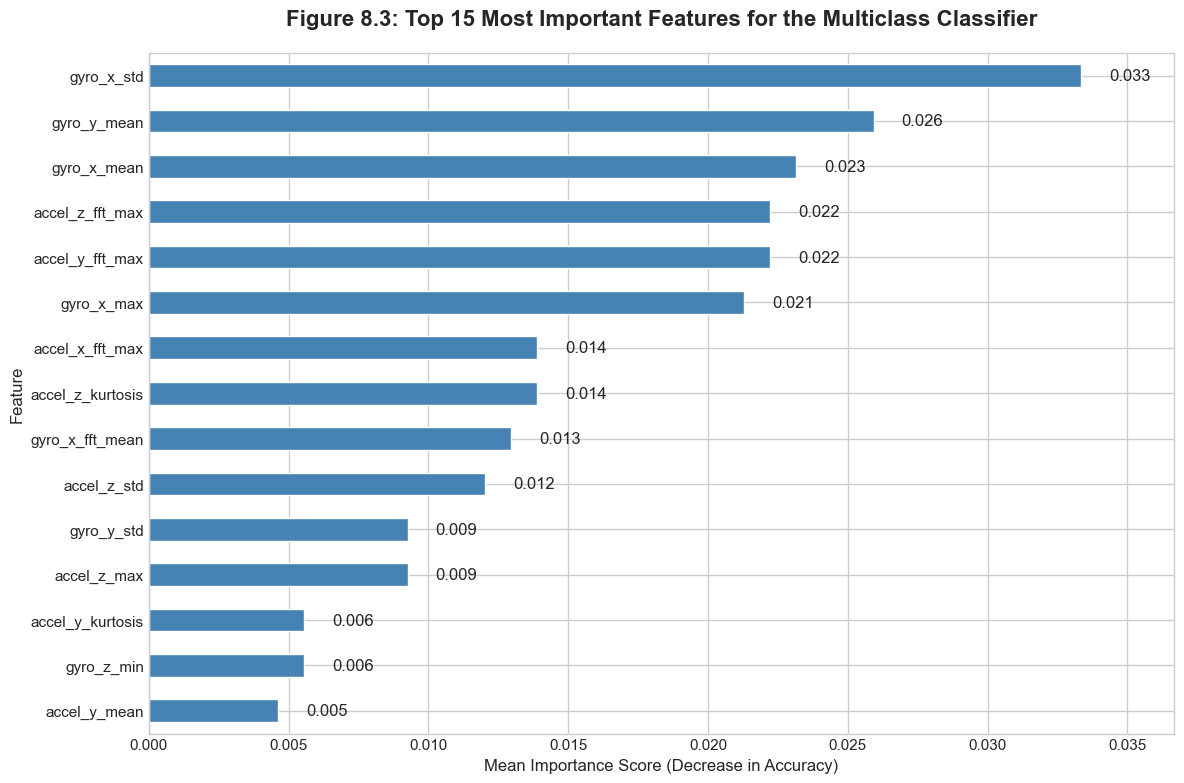

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

# This code assumes the trained multiclass model 'svm_multi', the scaled test data
# 'X_test_multi_scaled', 'y_test_multi', and the feature names list derived
# from 'X_train_multi_df' are available in memory.

try:
    print("--- Calculating Feature Importance using Permutation Importance ---")

    # --- 1. Calculate Permutation Importance ---
    # This repeatedly shuffles each feature and measures the drop in model accuracy.
    # It's computationally intensive but provides a robust measure of importance.
    # n_repeats=5 gives a more stable estimate.
    result = permutation_importance(
        svm_multi,
        X_test_multi_scaled,
        y_test_multi,
        n_repeats=5,
        random_state=42,
        n_jobs=-1,  # Use all available CPU cores
    )

    # --- 2. Organize the results ---
    # Create a pandas Series for easy sorting and plotting
    feature_names = list(X_train_multi_df.columns)
    importance_series = pd.Series(result.importances_mean, index=feature_names)

    # Get the top 15 most important features
    top_features = importance_series.nlargest(15)

    print(f"Top 5 most important features:\n{top_features.head()}")

    # --- 3. Visualization ---
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 8))

    # Create a horizontal bar chart
    top_features.sort_values(ascending=True).plot(kind="barh", ax=ax, color="steelblue")

    # --- 4. Labels, Title, and Formatting ---
    ax.set_xlabel("Mean Importance Score (Decrease in Accuracy)", fontsize=12)
    ax.set_ylabel("Feature", fontsize=12)
    ax.set_title(
        "Figure 8.3: Top 15 Most Important Features for the Multiclass Classifier",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )

    # Add value labels to the end of each bar
    for i, (feature, importance) in enumerate(
        top_features.sort_values(ascending=True).items()
    ):
        ax.text(importance + 0.001, i, f"{importance:.3f}", va="center")

    ax.margins(x=0.1)  # Add some padding to the x-axis
    plt.tight_layout()
    plt.show()

except NameError as e:
    print(f"--- ERROR: Required variable not found ---")
    print(f"Details: {e}")
    print(
        "Please ensure the multiclass model ('svm_multi'), test data, and feature names ('X_train_multi_df') are available."
    )
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Analysis of 216 test predictions:
  - Correct predictions: 160
  - Incorrect predictions: 56
  - Average confidence of incorrect predictions: 54.39%


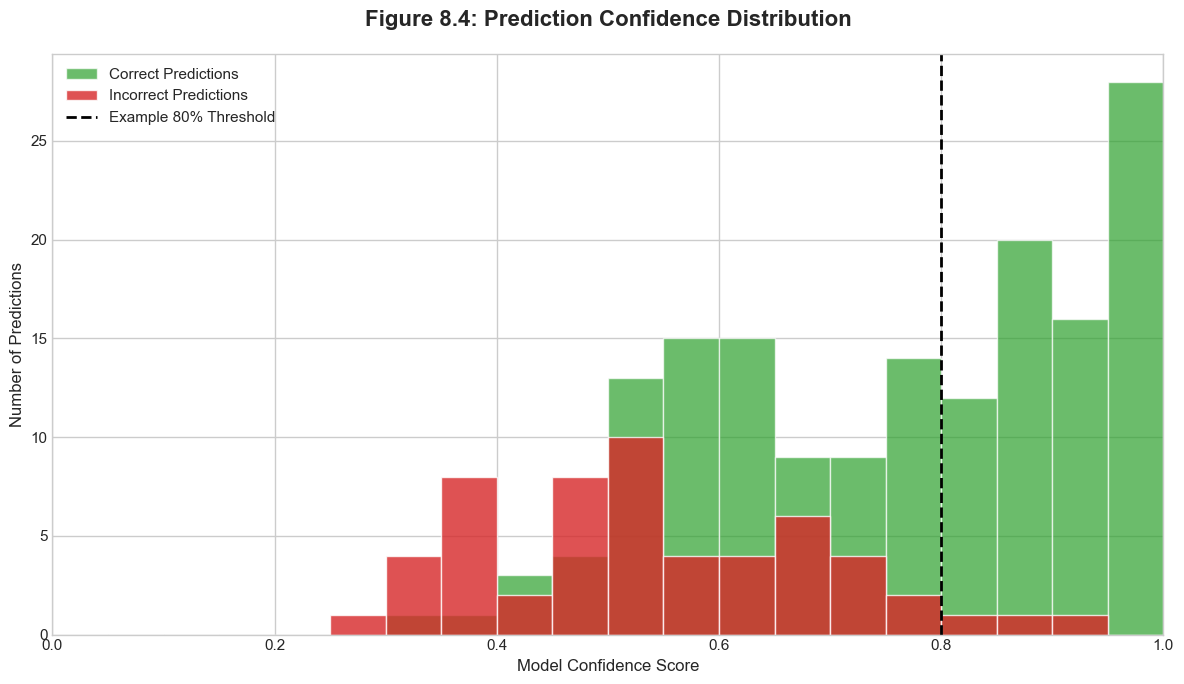

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# This code assumes the prediction probabilities 'y_proba_multi' and the true/predicted
# labels 'y_test_multi' and 'y_pred_multi' are available from Section 7.

try:
    # --- 1. Identify Correct and Incorrect Predictions ---
    correct_mask = y_test_multi == y_pred_multi
    incorrect_mask = ~correct_mask

    # --- 2. Get the confidence scores for each group ---
    # The confidence is the maximum probability value for each prediction
    confidences_correct = y_proba_multi[correct_mask].max(axis=1)
    confidences_incorrect = y_proba_multi[incorrect_mask].max(axis=1)

    print(f"Analysis of {len(y_proba_multi)} test predictions:")
    print(f"  - Correct predictions: {len(confidences_correct)}")
    print(f"  - Incorrect predictions: {len(confidences_incorrect)}")
    if len(confidences_incorrect) > 0:
        print(
            f"  - Average confidence of incorrect predictions: {np.mean(confidences_incorrect):.2%}"
        )

    # --- 3. Visualization ---
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 7))

    # Plot two histograms on top of each other
    ax.hist(
        confidences_correct,
        bins=np.linspace(0, 1, 21),
        alpha=0.7,
        label="Correct Predictions",
        color="#2ca02c",
    )  # Green
    ax.hist(
        confidences_incorrect,
        bins=np.linspace(0, 1, 21),
        alpha=0.8,
        label="Incorrect Predictions",
        color="#d62728",
    )  # Red

    # --- 4. Labels, Title, and Formatting ---
    ax.set_xlabel("Model Confidence Score", fontsize=12)
    ax.set_ylabel("Number of Predictions", fontsize=12)
    ax.set_title(
        "Figure 8.4: Prediction Confidence Distribution",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )

    # Add a vertical line to show a potential threshold
    ax.axvline(
        x=0.8, color="black", linestyle="--", linewidth=2, label="Example 80% Threshold"
    )

    ax.legend(fontsize=11)
    ax.set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

except NameError as e:
    print(f"--- ERROR: Required variable not found ---")
    print(f"Details: {e}")
    print(
        "Please ensure the prediction code cell (Section 7) has been run successfully."
    )

In [ ]:
import graphviz

# This code generates a high-level flowchart of the entire project pipeline.
try:
    # --- Graph Initialization ---
    dot = graphviz.Digraph(
        "ML_Pipeline", comment="End-to-End Machine Learning Pipeline"
    )
    dot.attr(
        rankdir="TB",
        splines="ortho",
        concentrate="true",
        label="Figure 9.1: The Full Machine Learning Pipeline",
        fontsize="20",
        fontname="Helvetica",
        labelloc="t",
        labeljust="l",
        fontcolor="black",
    )
    dot.attr(
        "node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="11"
    )
    dot.attr("edge", fontname="Helvetica", fontsize="10")

    # --- 1. Data Collection Stage ---
    with dot.subgraph(name="cluster_collection") as c:
        c.attr(
            label="Stage 1: Data Collection",
            style="rounded,filled",
            color="#e8f4f8",
            fontcolor="black",
        )
        c.node("watch", "Custom Pixel Watch App\n(Raw IMU Stream)", fillcolor="white")
        c.node("phone", "Custom Phone App\n(Button-Press Labels)", fillcolor="white")
        c.node("backend", "Python Backend\n(Sync & Save to CSV)", fillcolor="white")
        c.edge("watch", "backend", label="UDP Stream")
        c.edge("phone", "backend", label="UDP Stream")

    # --- 2. Preprocessing Stage ---
    with dot.subgraph(name="cluster_preprocessing") as c:
        c.attr(
            label="Stage 2: Preprocessing & Feature Engineering",
            style="rounded,filled",
            color="#e6f5e9",
            fontcolor="black",
        )
        c.node("load", "Load & Validate 791 CSVs")
        c.node("features", "Extract 48 Time/Frequency Features")
        c.node("split", "Stratified 70/30 Train-Test Split")
        c.node("scale", "StandardScaler (Fit on Train Set)")
        c.edge("load", "features")
        c.edge("features", "split")
        c.edge("split", "scale")

    # --- 3. Model Training Stage ---
    with dot.subgraph(name="cluster_training") as c:
        c.attr(
            label="Stage 3: Model Training",
            style="rounded,filled",
            color="#fef5e7",
            fontcolor="black",
        )
        c.node(
            "svm",
            "Train SVMs (RBF Kernel, C=10)\n- Binary (Walk/Idle)\n- Multiclass (6 Gestures)",
        )
        c.node("pkl", "Persist Models to Disk (.pkl)", shape="note", fillcolor="white")
        c.edge("svm", "pkl")

    # --- 4. Evaluation Stage ---
    with dot.subgraph(name="cluster_evaluation") as c:
        c.attr(
            label="Stage 4: Evaluation",
            style="rounded,filled",
            color="#fdedec",
            fontcolor="black",
        )
        c.node("predict", "Predict on Unseen Test Set")
        c.node(
            "metrics", "Compute Metrics & Visualize\n(Accuracy, F1, Confusion Matrix)"
        )
        c.node(
            "results",
            "Final Results\nBinary: 93.1%\nMulticlass: 74.1%",
            shape="ellipse",
            fillcolor="white",
        )
        c.edge("predict", "metrics")
        c.edge("metrics", "results")

    # --- Connect the main stages ---
    dot.edge("backend", "load", lhead="cluster_preprocessing")
    dot.edge("scale", "svm", lhead="cluster_training")
    dot.edge("pkl", "predict", lhead="cluster_evaluation")

    # --- Render and Save ---
    output_filename = "full_pipeline_diagram"
    dot.render(output_filename, format="png", cleanup=True, view=False)
    print(f"✅ Pipeline diagram saved as '{output_filename}.png'")

except Exception as e:
    print(f"--- ERROR: Could not generate flowchart. ---")
    print(
        "Please ensure 'graphviz' is installed (pip install graphviz) and that the Graphviz system package is in your PATH."
    )
    print(f"Details: {e}")

✅ Pipeline diagram saved as 'full_pipeline_diagram.png'


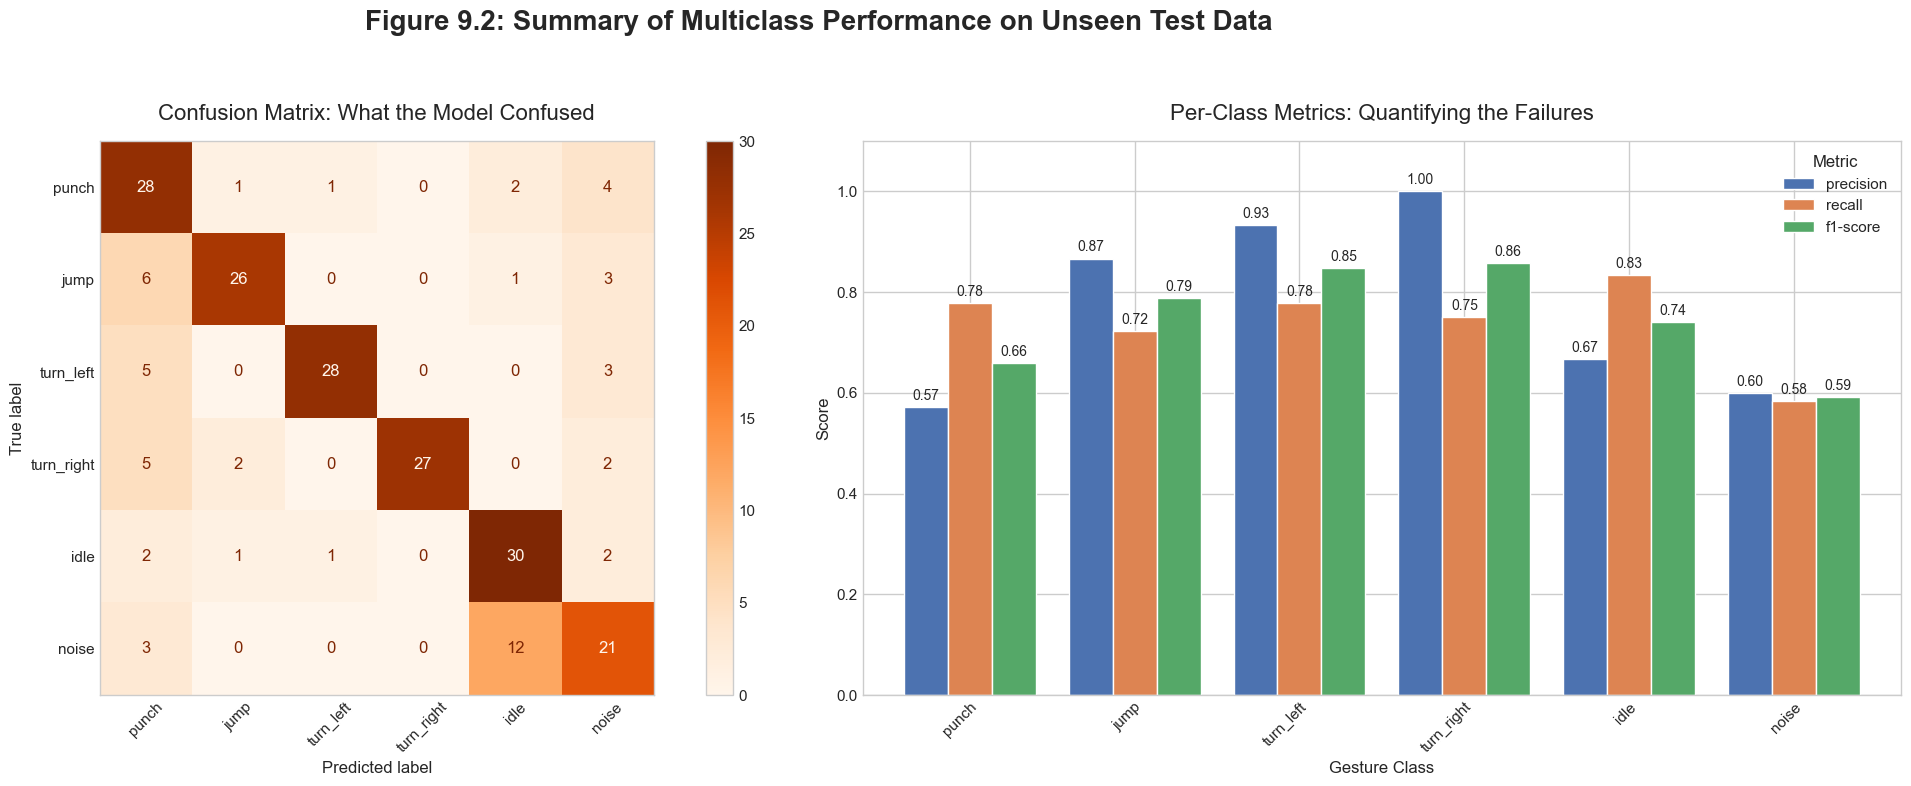

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# This code assumes the variables from the evaluation in Section 7 are available.
# (y_test_multi, y_pred_multi, MULTICLASS_CLASSES)

try:
    # --- Create a figure with two side-by-side subplots ---
    fig, axes = plt.subplots(1, 2, figsize=(22, 8))
    fig.suptitle(
        "Figure 9.2: Summary of Multiclass Performance on Unseen Test Data",
        fontsize=20,
        fontweight="bold",
    )

    # --- Subplot 1 (Left): Confusion Matrix ---
    cm_multi = confusion_matrix(
        y_test_multi, y_pred_multi, labels=range(len(MULTICLASS_CLASSES))
    )
    disp_multi = ConfusionMatrixDisplay(
        confusion_matrix=cm_multi, display_labels=MULTICLASS_CLASSES
    )

    disp_multi.plot(ax=axes[0], cmap="Oranges", values_format="d")
    axes[0].set_title("Confusion Matrix: What the Model Confused", fontsize=16, pad=15)
    axes[0].grid(False)
    axes[0].tick_params(axis="x", rotation=45)

    # --- Subplot 2 (Right): Per-Class Performance Metrics ---
    report_dict = classification_report(
        y_test_multi,
        y_pred_multi,
        target_names=MULTICLASS_CLASSES,
        output_dict=True,
        labels=range(len(MULTICLASS_CLASSES)),
    )
    class_metrics = {
        class_name: report_dict[class_name] for class_name in MULTICLASS_CLASSES
    }
    metrics_df = pd.DataFrame(class_metrics).T.drop(columns="support")

    metrics_df.plot(kind="bar", ax=axes[1], width=0.8)
    axes[1].set_title(
        "Per-Class Metrics: Quantifying the Failures", fontsize=16, pad=15
    )
    axes[1].set_ylabel("Score")
    axes[1].set_xlabel("Gesture Class")

    # --- THIS IS THE FIX ---
    # Instead of using tick_params, we set the label properties directly.
    # The 'ha="right"' aligns the end of the label text with the tick.
    plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    axes[1].legend(title="Metric")
    axes[1].set_ylim(0, 1.1)

    # Add text labels to the bars
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt="%.2f", fontsize=10, padding=3)

    plt.tight_layout(rect=[0, 0, 1, 0.94])  # Adjust layout for main title
    plt.show()

except NameError as e:
    print(f"--- ERROR: Required variable not found ---")
    print(f"Details: {e}")
    print(
        "Please ensure the prediction and evaluation cells from Section 7 have been run successfully."
    )